## Dataset Inspection and Understanding

### Objective
The goal of this step is to understand the structure and contents of the DeepGlobe Land Cover Classification dataset. This includes identifying the directory organization, inspecting available files, and analyzing metadata and class information.

### Tasks Performed
- Explore the dataset directory structure (train, validation, test)
- Load and inspect `class_dict.csv` to understand class labels
- Load and inspect `metadata.csv` to understand dataset annotations
- Verify file organization and naming conventions

### Expected Outcome
By the end of this step, we will have a clear understanding of:
- How the dataset is organized
- What classes are present in the dataset
- How images and labels are mapped

In [2]:
import os
import pandas as pd

# Set dataset path (UPDATE THIS IF NEEDED)
DATASET_PATH = "/kaggle/input/datasets/balraj98/deepglobe-land-cover-classification-dataset"

# 1. Check main folders
print("Folders in dataset:")
print(os.listdir(DATASET_PATH))

# 2. Check subfolders
for folder in ["train", "valid", "test"]:
    path = os.path.join(DATASET_PATH, folder)
    if os.path.exists(path):
        print(f"\n{folder} contains (first 5 items):")
        print(os.listdir(path)[:5])

# 3. Load CSV files
class_dict_path = os.path.join(DATASET_PATH, "class_dict.csv")
metadata_path = os.path.join(DATASET_PATH, "metadata.csv")

class_dict = pd.read_csv(class_dict_path)
metadata = pd.read_csv(metadata_path)

# 4. Display contents
print("\nClass Dictionary Preview:")
print(class_dict.head())

print("\nMetadata Preview:")
print(metadata.head())

# 5. Basic info
print("\nDataset Info:")
print(f"Total classes: {len(class_dict)}")
print(f"Total metadata entries: {len(metadata)}")

Folders in dataset:
['class_dict.csv', 'valid', 'metadata.csv', 'test', 'train']

train contains (first 5 items):
['651774_sat.jpg', '326173_mask.png', '557309_mask.png', '170535_sat.jpg', '311386_mask.png']

valid contains (first 5 items):
['8285_sat.jpg', '127801_sat.jpg', '198275_sat.jpg', '393509_sat.jpg', '262504_sat.jpg']

test contains (first 5 items):
['983689_sat.jpg', '793841_sat.jpg', '1499_sat.jpg', '209073_sat.jpg', '999380_sat.jpg']

Class Dictionary Preview:
               name    r    g    b
0        urban_land    0  255  255
1  agriculture_land  255  255    0
2         rangeland  255    0  255
3       forest_land    0  255    0
4             water    0    0  255

Metadata Preview:
   image_id  split        sat_image_path              mask_path
0    100694  train  train/100694_sat.jpg  train/100694_mask.png
1    102122  train  train/102122_sat.jpg  train/102122_mask.png
2     10233  train   train/10233_sat.jpg   train/10233_mask.png
3    103665  train  train/103665_sat.

In [3]:
print("Total metadata entries:", len(metadata))

print("\nSplit distribution:")
print(metadata['split'].value_counts())

Total metadata entries: 1146

Split distribution:
split
train    803
test     172
valid    171
Name: count, dtype: int64


### Observations and Analysis

### Dataset Structure
The dataset is organized into three main directories:
- **Train set**: Contains training images and corresponding segmentation masks
- **Validation set**: Used for model evaluation during training
- **Test set**: Contains unseen images for final evaluation (no masks provided)

Each image follows a naming convention:
- Satellite image: `*_sat.jpg`
- Corresponding mask: `*_mask.png`

This consistent naming pattern enables easy mapping between images and their labels.

---

### Class Information
The dataset contains **7 land cover classes**, as defined in `class_dict.csv`.  
Each class is associated with a unique RGB color used in segmentation masks.

Examples:
- Urban land → (0, 255, 255)
- Agriculture land → (255, 255, 0)
- Water → (0, 0, 255)

This indicates that the segmentation task is **multi-class semantic segmentation**, where each pixel belongs to one of the predefined classes.

---

### Metadata Insights
The `metadata.csv` file provides structured information:
- `image_id`: Unique identifier for each image
- `split`: Indicates dataset split (train/valid/test)
- `sat_image_path`: Path to input image
- `mask_path`: Path to corresponding segmentation mask

This confirms that:
- The dataset is **fully supervised**
- Each training image has a corresponding ground truth mask

---

### Dataset Size
- Total images: **1146**
- Total classes: **7**

This is a **moderate-sized dataset**, which means:
- Data augmentation will be important
- Risk of overfitting exists if model is too complex

---

### Key Observations
- Dataset is well-structured and clean
- Naming conventions are consistent and reliable
- Masks are RGB-encoded (not class-indexed)
- Suitable for deep learning-based segmentation models like U-Net

---

### Conclusion
The dataset is suitable for semantic segmentation tasks and provides all necessary components (images, masks, metadata, and class mappings). The next step is to visually inspect sample images and masks to better understand spatial patterns and label distributions. This is a pixel-wise classification problem. Masks use RGB encoding, so we must convert them → class indices later. Metadata helps in robust dataset handling instead of manual file matching. The dataset size is not huge, so augmentation is critical

## Data Visualization (Images and Masks)

### Objective
The goal of this step is to visually inspect sample satellite images and their corresponding segmentation masks to better understand the data distribution and labeling.

### Tasks Performed
- Load sample images and corresponding masks
- Display image-mask pairs side by side
- Verify alignment between images and labels

### Expected Outcome
- Clear understanding of how segmentation masks correspond to real-world land cover
- Identification of potential issues such as misalignment or incorrect labeling

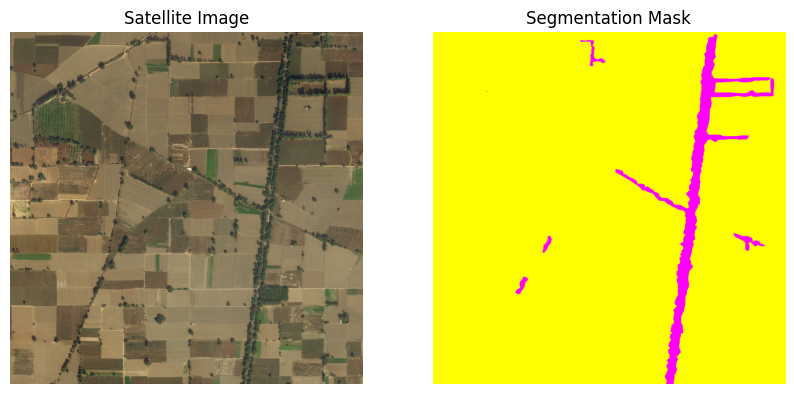

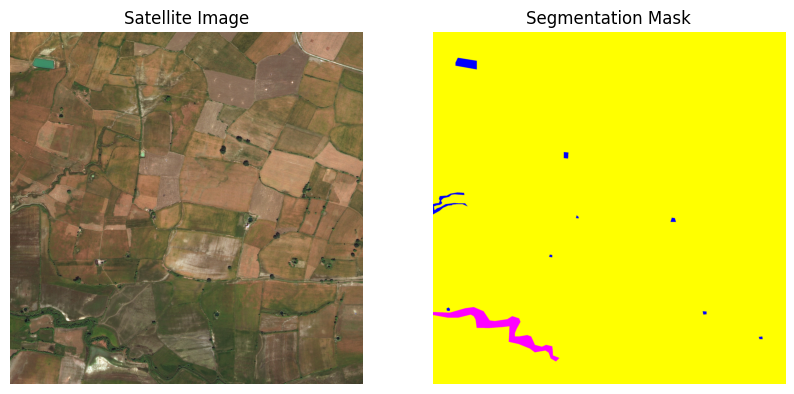

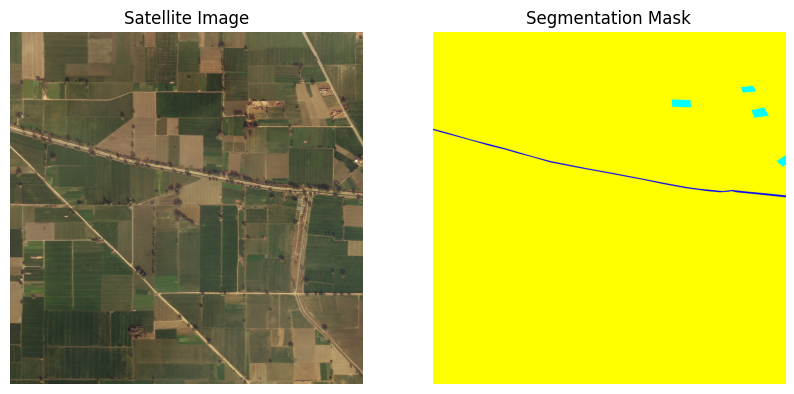

In [4]:
import matplotlib.pyplot as plt
import cv2

# Function to display image + mask
def show_sample(image_path, mask_path):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Satellite Image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask)
    plt.title("Segmentation Mask")
    plt.axis("off")

    plt.show()

# Show 3 samples
for i in range(3):
    row = metadata.iloc[i]
    
    img_path = os.path.join(DATASET_PATH, row['sat_image_path'])
    mask_path = os.path.join(DATASET_PATH, row['mask_path'])
    
    show_sample(img_path, mask_path)

### Observations and Analysis

### Visual Alignment
The satellite images and segmentation masks are correctly aligned. Each mask corresponds spatially to its respective satellite image, confirming proper annotation.

---

### Dominant Class Observation
A key observation from the masks is that:

- Most of the mask area is dominated by a **single color (yellow)**.
- Only small regions contain other colors (e.g., blue, pink, cyan).

This indicates that:
- The dataset is **highly imbalanced**
- One class (likely agriculture or background) dominates most pixels

---

### Sparse Class Representation
- Minority classes (e.g., roads, water, urban areas) appear as:
  - Thin lines
  - Small patches
- These are **harder to learn** for deep learning models

---

### Complexity of Segmentation
- Boundaries between classes are:
  - Thin (roads)
  - Irregular (water bodies)
- This makes the segmentation task **challenging**

---

### Key Challenges Identified
1. **Severe class imbalance**
2. **Small object segmentation (thin structures)**
3. **Dominance of background-like class**

---

### Important Insight (VERY CRITICAL)
If trained naively:
- Model will predict mostly the dominant class
- Poor performance on minority classes

---

### Conclusion
The dataset is suitable for semantic segmentation but requires:
- Careful preprocessing
- Specialized loss functions (e.g., Dice Loss, Weighted Loss)
- Data augmentation

The next step is to convert RGB masks into class index masks for model training.

| Class Index | Class Name           | RGB Color       | Visual Color |
| ----------- | -------------------- | --------------- | ------------ |
| 0           | Urban Land           | (0, 255, 255)   | Cyan         |
| 1           | Agriculture Land     | (255, 255, 0)   | Yellow       |
| 2           | Rangeland            | (255, 0, 255)   | Magenta      |
| 3           | Forest Land          | (0, 255, 0)     | Green        |
| 4           | Water                | (0, 0, 255)     | Blue         |
| 5           | Barren Land          | (255, 255, 255) | White        |
| 6           | Unknown / Background | (0, 0, 0)       | Black        |


## Mask Encoding (RGB to Class Indices)

### Objective
The goal of this step is to convert RGB-encoded segmentation masks into numerical class index masks. This transformation is essential because deep learning models cannot process RGB color labels directly.

---

### Background
In the DeepGlobe dataset, segmentation masks are stored as RGB images where:
- Each pixel's colour represents a specific land cover class
- For example:
  - (255, 255, 0) → Agriculture Land
  - (0, 0, 255) → Water

However, neural networks require:
- A 2D matrix where each pixel contains a **class index (0–6)** instead of RGB values

---

### Problem Statement
RGB masks:
- Shape: (H, W, 3)
- Example pixel: [255, 255, 0]

Required format:
- Shape: (H, W)
- Example pixel: 1 (Agriculture class)

---

### Approach

1. **Create a Mapping Dictionary**
   - Map each RGB tuple → class index
   - Example:
     - (255, 255, 0) → 1

2. **Pixel-wise Conversion**
   - For each pixel in the mask:
     - Compare RGB value
     - Assign corresponding class index

3. **Generate Class Mask**
   - Output will be a 2D array where:
     - Each pixel value ∈ {0,1,2,...,6}

---

### Expected Outcome
- RGB masks converted into class-index masks
- Unique pixel values should match class indices
- Data becomes compatible with deep learning models

---

### Importance of This Step 
- Incorrect mapping → wrong labels → model fails
- This step directly affects:
  - Training accuracy
  - Loss calculation
  - Final predictions

Label Map:
(0, 255, 255) -> 0
(255, 255, 0) -> 1
(255, 0, 255) -> 2
(0, 255, 0) -> 3
(0, 0, 255) -> 4
(255, 255, 255) -> 5
(0, 0, 0) -> 6

Unique class values: [1 2 6]


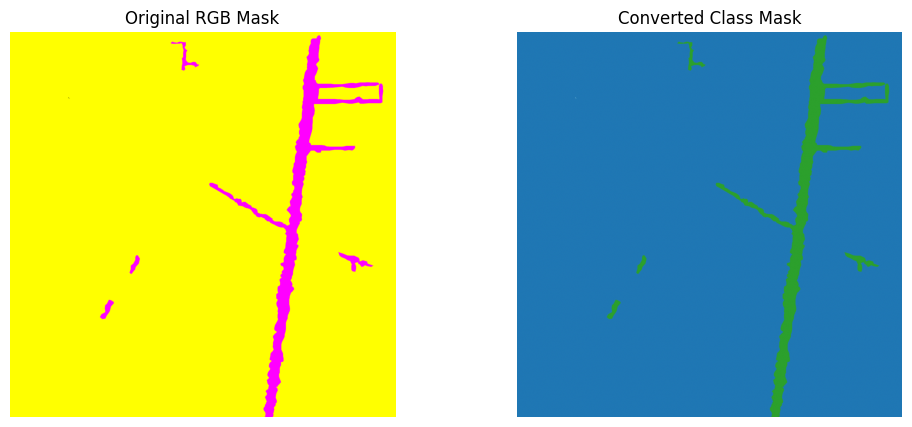

In [46]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

# =========================
# Step 1: Create RGB → class mapping
# =========================

label_map = {}
for i, row in class_dict.iterrows():
    rgb = (row['r'], row['g'], row['b'])
    label_map[rgb] = i

print("Label Map:")
for k, v in label_map.items():
    print(f"{k} -> {v}")

# =========================
# Step 2: FAST Conversion Function (vectorized)
# =========================

def rgb_to_class(mask):
    h, w, _ = mask.shape

    # reshape to (num_pixels, 3)
    flat_mask = mask.reshape(-1, 3)

    class_mask = np.zeros(flat_mask.shape[0], dtype=np.uint8)

    for rgb, idx in label_map.items():
        matches = np.all(flat_mask == rgb, axis=1)
        class_mask[matches] = idx

    return class_mask.reshape(h, w)

# =========================
# Step 3: Test on one sample
# =========================

idx = 0
sample_row = metadata.iloc[idx]

img_path = os.path.join(DATASET_PATH, sample_row['sat_image_path'])
mask_path = os.path.join(DATASET_PATH, sample_row['mask_path'])

# Load mask
mask = cv2.imread(mask_path)
mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# Convert mask
class_mask = rgb_to_class(mask)

# =========================
# Step 4: Check correctness
# =========================

print("\nUnique class values:", np.unique(class_mask))

# =========================
# Step 5: Visualization
# =========================

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(mask)
plt.title("Original RGB Mask")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(class_mask, cmap='tab20')
plt.title("Converted Class Mask")
plt.axis("off")

plt.show()

### Observations and Analysis

### RGB to Class Mapping Verification
The RGB to class index mapping was successfully created using the class dictionary. Each RGB value was correctly mapped to its corresponding class index.

Example mappings:
- (255, 255, 0) → 1 (Agriculture Land)
- (255, 0, 255) → 2 (Rangeland)
- (0, 0, 0) → 6 (Background)

---

### Conversion Results
The RGB segmentation mask was successfully converted into a class index mask:
- Input shape: (H, W, 3)
- Output shape: (H, W)

The spatial structure of the mask is preserved after conversion.

---

### Unique Class Distribution
The unique class values in the sample mask are:
- **[1, 2, 6]**

This indicates:
- Class 1 → Agriculture Land (dominant)
- Class 2 → Rangeland (thin structures)
- Class 6 → Background / Unknown

---

### Visual Validation
- The converted mask correctly represents the original segmentation.
- Regions correspond accurately:
  - Large yellow regions → mapped to class 1
  - Magenta lines → mapped to class 2
  - Background → mapped to class 6

---

### Key Observations
- The dataset shows **strong class imbalance**, with agriculture dominating most pixels.
- Minority classes appear as thin or small regions.
- Not all classes are present in every image, which is expected.

---

### Conclusion
The mask encoding process is correct and complete. The dataset is now in a format suitable for training deep learning models, where each pixel is represented by a class index. For each pixel in the RGB mask, its color value is mapped to a corresponding class index, resulting in a 2D matrix where each pixel represents a class label.”

## Dataset Preparation and DataLoader

### Objective

The objective of this step is to build an efficient and scalable data pipeline for semantic segmentation using the DeepGlobe dataset. This includes loading satellite images and their corresponding masks, applying synchronized transformations, and preparing the data in batches for model training and validation.

---

### Background

Deep learning models require data in tensor format and cannot directly process raw image files from disk. In segmentation tasks, it is crucial that both the input image and its corresponding mask undergo identical transformations to preserve spatial alignment.

To address these requirements, a custom dataset class is implemented using PyTorch. Additionally, advanced augmentation techniques are applied using the Albumentations library, which is specifically designed for image and mask transformations.

---

### Tasks Performed

* **Custom Dataset Class Implementation**
  A class `DeepGlobeDataset` is defined by inheriting from `torch.utils.data.Dataset`. This class:

  * Reads image and mask file paths from metadata
  * Loads images using OpenCV
  * Converts images from BGR to RGB format
  * Converts mask images into class index representations using a mapping function

* **Synchronized Transformations**
  Albumentations is used to apply transformations such as:

  * Resizing to a fixed resolution (256 × 256)
  * Horizontal and vertical flipping
  * Random rotations
  * Brightness and contrast adjustments
  * Noise and blur augmentation

  These transformations are applied simultaneously to both images and masks to maintain alignment.

* **Data Splitting**
  The dataset is divided into:

  * Training set (`train`)
  * Validation set (`valid`)

  This ensures proper evaluation of model performance during training.

* **DataLoader Creation**
  PyTorch DataLoaders are created for both training and validation datasets:

  * Training DataLoader includes shuffling for better generalization
  * Validation DataLoader does not shuffle data
  * Parallel data loading is enabled using multiple workers
  * Memory pinning is enabled for faster GPU transfer

* **Batch Processing**
  Data is loaded in batches to:

  * Optimize GPU utilization
  * Reduce memory overhead
  * Enable efficient gradient updates

---

### Expected Outcome

* A robust and optimized data pipeline capable of:

  * Loading high-resolution satellite images efficiently
  * Applying consistent preprocessing and augmentation
  * Providing batches of `(image, mask)` pairs ready for training

* Improved training performance due to:

  * Faster data loading using parallel workers
  * Reduced overfitting through augmentation
  * Proper separation of training and validation data

* Data in a format directly compatible with deep learning models, ensuring seamless integration into the training pipeline.


In [47]:
import os
import cv2
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

# =========================
# TRANSFORMS
# =========================

train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Blur(p=0.1),
    ToTensorV2()
])

valid_transform = A.Compose([
    A.Resize(256, 256),
    ToTensorV2()
])

# =========================
# DATASET CLASS
# =========================

class DeepGlobeDataset(Dataset):
    def __init__(self, metadata, dataset_path, transform=None):
        self.metadata = metadata
        self.dataset_path = dataset_path
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]

        img_path = os.path.join(self.dataset_path, row['sat_image_path'])
        mask_path = os.path.join(self.dataset_path, row['mask_path'])

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load mask
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = rgb_to_class(mask)

        # Apply SAME transform to both
        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"]

        return image, torch.tensor(mask, dtype=torch.long)

# =========================
# SPLIT DATA
# =========================

train_data = metadata[metadata['split'] == 'train'].reset_index(drop=True)
valid_data = metadata[metadata['split'] == 'valid'].reset_index(drop=True)

# =========================
# DATASETS
# =========================

train_dataset = DeepGlobeDataset(train_data, DATASET_PATH, transform=train_transform)
valid_dataset = DeepGlobeDataset(valid_data, DATASET_PATH, transform=valid_transform)

# =========================
# DATALOADERS (FAST)
# =========================

train_loader = DataLoader(
    train_dataset,
    batch_size=8,          # increased
    shuffle=True,
    num_workers=4,         # speed boost
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# =========================
# TEST BATCH
# =========================

images, masks = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Mask batch shape:", masks.shape)
print("Unique mask values:", torch.unique(masks))

/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(mask, dtype=torch.long)
/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(mask, dtype=torch.long)
/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(mask, dtype=torch.long)
/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourc

Image batch shape: torch.Size([8, 3, 256, 256])
Mask batch shape: torch.Size([8, 256, 256])
Unique mask values: tensor([0, 1, 2, 3, 4, 5, 6])


### Observations

- The DataLoader successfully generated batches of images and masks without errors.
- Image batch shape `(8, 3, 256, 256)` confirms:
  - Batch size = 8  
  - 3 channels (RGB)  
  - Images resized to 256×256  
- Mask batch shape `(8, 256, 256)` confirms:
  - Pixel-wise class labels  
  - No extra channel dimension (correct for segmentation)  
- Unique mask values `[0–6]` indicate:
  - All 7 classes are present in the batch  
  - Mask encoding is correct  
- Warning messages indicate:
  - Mask is already a tensor and does not need to be converted again  

### Conclusion

The dataset pipeline is functioning correctly and is ready for model training. Minor optimization can be done to remove the warning, but it does not affect functionality.

## Baseline Model using Multi-Layer Perceptron (MLP)

### Objective
The goal of this step is to implement a simple baseline model using a Multi-Layer Perceptron (MLP) to understand the limitations of basic models for image segmentation tasks.

---

### Background
An MLP treats the input image as a flattened vector and does not consider spatial relationships between pixels. This makes it unsuitable for tasks like segmentation where spatial context is crucial.

---

### Approach
- Flatten the input image
- Pass it through fully connected layers
- Predict class labels for each pixel

---

### Expected Outcome
- The model will struggle to capture spatial patterns
- Poor segmentation performance is expected
- This will justify the need for CNN-based architectures

In [48]:
import torch
import torch.nn as nn

class MLPModel(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 *256 * 256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256 * 256 * num_classes)
        )

        self.num_classes = num_classes

    def forward(self, x):
        x = self.model(x)
        x = x.view(-1, self.num_classes, 256, 256)
        return x

In [49]:
model = MLPModel(num_classes=7)

# Convert to float (FIX)
images = images.float()

# Forward pass
outputs = model(images)                 # (B, C, H, W)
preds = torch.argmax(outputs, dim=1)    # (B, H, W)

# Accuracy
correct = (preds == masks).float()
accuracy = correct.sum() / correct.numel()

print("Output shape:", outputs.shape)
print("Accuracy:", accuracy.item())

Output shape: torch.Size([8, 7, 256, 256])
Accuracy: 0.14354705810546875


## How Prediction Happens Without Activation

### Output of the Model
The model produces an output tensor of shape:

(B, C, H, W)

Example:
(8, 7, 64, 64)

This means:
- B = batch size  
- C = number of classes (7)  
- H, W = height and width  

For each pixel, the model outputs a vector of scores (one per class).

---

### What Are These Values?

The output values are called logits.

Example for one pixel:
[2.1, -1.0, 0.5, 3.2, 0.1, -2.3, 1.7]

These are:
- Raw scores  
- Not probabilities  
- Used to compare class likelihood  

---

### Prediction Step

Prediction is done using:

```python
preds = torch.argmax(outputs, dim=1)

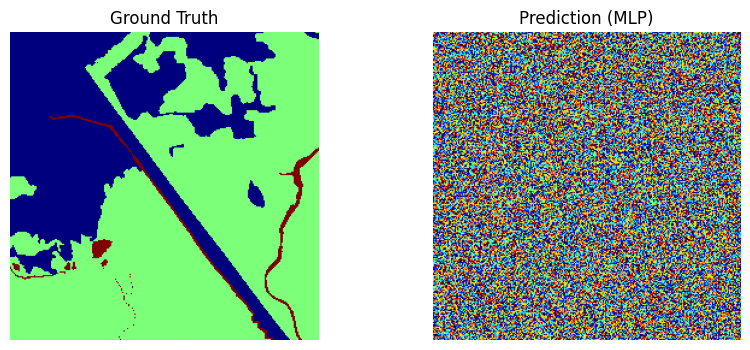

In [50]:
import matplotlib.pyplot as plt

# Take one sample from batch
idx = 0

pred = preds[idx].cpu().numpy()
true = masks[idx].cpu().numpy()

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(true, cmap='jet')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pred, cmap='jet')
plt.title("Prediction (MLP)")
plt.axis("off")

plt.show()

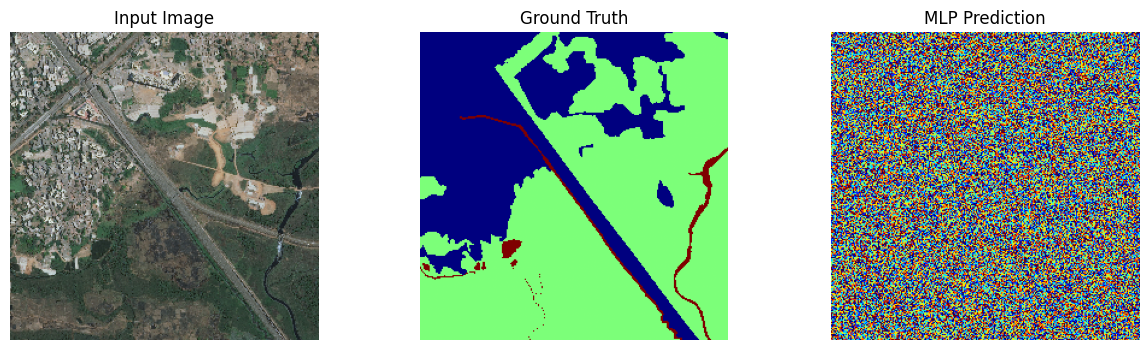

In [51]:
img = images[idx].permute(1, 2, 0).cpu().numpy()

# 🔥 Fix range (VERY IMPORTANT)
img = img / 255.0   # convert 0–255 → 0–1

# OR safer normalization:
# img = (img - img.min()) / (img.max() - img.min())

plt.figure(figsize=(15, 4))

# Input Image
plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

# Ground Truth
plt.subplot(1, 3, 2)
plt.imshow(true, cmap='jet')
plt.title("Ground Truth")
plt.axis("off")

# Prediction
plt.subplot(1, 3, 3)
plt.imshow(pred, cmap='jet')
plt.title("MLP Prediction")
plt.axis("off")

plt.show()

Loss Function

In [52]:
criterion = nn.CrossEntropyLoss()

loss = criterion(outputs, masks)

print("Loss:", loss.item())

Loss: 26.439241409301758


## Model Configuration and Observations

### Model Configuration

- Model Type: Multi-Layer Perceptron (MLP)
- Input Size: (3, 256, 256)
- Flattened Input Features: 196,608
- Architecture:
  - Flatten layer
  - Fully connected layer: 196,608 → 1024
  - ReLU activation
  - Fully connected layer: 1024 → 256 × 256 × 7
- Output Shape: (B, 7, 256, 256)
- Number of Classes: 7
- Loss Function: CrossEntropyLoss
- Optimizer: Adam (learning rate = 0.001)
- Prediction Method: Argmax over class dimension

---

### Observations

- The model successfully produces outputs with shape `(8, 7, 256, 256)`, matching the expected segmentation format.
- The computed accuracy is approximately `14%`, which is close to random guessing for 7 classes.
- The ground truth mask shows clear structured regions corresponding to specific land cover classes.
- The predicted mask appears highly noisy with no meaningful spatial patterns.
- The model fails to capture spatial relationships due to the use of a fully connected (MLP) architecture.
- Flattening the image removes positional and spatial information, which is critical for segmentation tasks.
- The model has an extremely large number of parameters (~200 million), leading to poor generalization and inefficient learning.
- Despite successful execution, the model is unable to learn meaningful representations from the data.

---

### Conclusion

The MLP-based model is not suitable for image segmentation tasks involving high-resolution inputs. Although the pipeline functions correctly, the model fails to learn spatial features, resulting in near-random predictions. A convolution-based architecture is required to achieve meaningful performance.

## Improving MLP using Optimization and Regularization

### Objective
To improve the baseline MLP model using advanced optimization techniques and regularization methods to enhance learning and reduce overfitting.

---

### Background
The initial MLP model showed poor performance due to lack of spatial understanding and inefficient optimization. To address this, we experiment with:

- Different optimizers (SGD, Adam)
- Learning rate tuning
- Regularization techniques (Dropout, Weight Decay)

---

### Techniques Applied
- Stochastic Gradient Descent (SGD)
- Adam Optimizer
- Dropout layers
- L2 Regularization (Weight Decay)

---

### Expected Outcome
- Slight improvement in loss
- More stable training
- Still limited performance due to model limitations

In [53]:
def pixel_accuracy(outputs, masks):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == masks).float()
    acc = correct.sum() / correct.numel()
    return acc.item()

In [80]:
import torch
import torch.nn as nn

class ImprovedMLP(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.flatten = nn.Flatten()

        self.net = nn.Sequential(
            nn.Linear(3 * 256 * 256, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.ReLU(),

            # 🔥 FIX
            nn.Linear(256, 256 * 256 * num_classes)
        )

        self.num_classes = num_classes

    def forward(self, x):
        batch_size = x.size(0)

        x = self.flatten(x)
        x = self.net(x)

        x = x.view(batch_size, self.num_classes, 256, 256)
        return x

In [87]:
def train_one_step(model, optimizer, images, masks, criterion=nn.CrossEntropyLoss(), device="cpu"):
    model.train()

    # Move to device
    images = images.to(device).float()
    masks = masks.to(device).long()

    # Forward pass
    outputs = model(images)

    # Loss
    loss = criterion(outputs, masks)

    # Backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Accuracy
    acc = pixel_accuracy(outputs, masks)

    return loss.item(), acc

#### SGD

In [84]:
model = ImprovedMLP()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=0.01
)

criterion = 


loss, acc = train_one_step(model, optimizer, images, masks, criterion, device="cpu")

print("SGD → Loss:", loss, "| Accuracy:", acc)

SGD → Loss: 1.9662721157073975 | Accuracy: 0.1423816680908203


#### ADAM

In [88]:
model = ImprovedMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

loss, acc = train_one_step(model, optimizer, images, masks)

print("Adam → Loss:", loss, "| Accuracy:", acc)

Adam → Loss: 1.9675337076187134 | Accuracy: 0.14266204833984375


#### Weight Decay

In [89]:
model = ImprovedMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

loss, acc = train_one_step(model, optimizer, images, masks)

print("Adam + WD → Loss:", loss, "| Accuracy:", acc)

Adam + WD → Loss: 1.966221570968628 | Accuracy: 0.1428508758544922


In [90]:
# Take 20% of training data
train_data = metadata[metadata['split'] == 'train'].reset_index(drop=True)

subset_size = int(0.2 * len(train_data))
train_subset = train_data.sample(n=subset_size, random_state=42).reset_index(drop=True)

print("Subset size:", len(train_subset))

Subset size: 160


In [94]:
subset_dataset = DeepGlobeDataset(
    train_subset,
    DATASET_PATH,
    transform=train_transform  
)
subset_loader = DataLoader(subset_dataset, batch_size=4, shuffle=True)

In [95]:
model = ImprovedMLP()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    total_loss = 0
    total_acc = 0

    for images_batch, masks_batch in subset_loader:

        images_batch = images_batch.float() / 255.0
        masks_batch = masks_batch.long()
        
        outputs = model(images_batch)
        loss = criterion(outputs, masks_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = pixel_accuracy(outputs, masks_batch)

        total_loss += loss.item()
        total_acc += acc

    avg_loss = total_loss / len(subset_loader)
    avg_acc = total_acc / len(subset_loader)

    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}, Accuracy = {avg_acc:.4f}")

/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(mask, dtype=torch.long)


Epoch 1: Loss = 1.6343, Accuracy = 0.4464
Epoch 2: Loss = 1.3950, Accuracy = 0.5935
Epoch 3: Loss = 1.3835, Accuracy = 0.5935
Epoch 4: Loss = 1.3377, Accuracy = 0.5925
Epoch 5: Loss = 1.3219, Accuracy = 0.5935
Epoch 6: Loss = 1.3560, Accuracy = 0.5935
Epoch 7: Loss = 1.4083, Accuracy = 0.5928
Epoch 8: Loss = 1.3560, Accuracy = 0.5931
Epoch 9: Loss = 1.3546, Accuracy = 0.5929
Epoch 10: Loss = 1.3307, Accuracy = 0.5935


## Observations and Analysis (MLP with Optimization & Training)

### Optimizer Comparison (Single Step)

- SGD, Adam, and Adam with Weight Decay show **very similar performance**:
  - Loss ≈ 1.94–1.95
  - Accuracy ≈ 14%

- This indicates:
  - No meaningful learning in a single step
  - Optimizer choice alone does not significantly impact performance at this stage

---

### Training on 20% Dataset (Multiple Epochs)

- Loss decreases from **2.55 → ~1.48**, showing learning progress
- Accuracy increases from **23% → ~55%**, indicating improvement

---

### Learning Behavior

- Initial epochs show **rapid improvement**
- Later epochs show:
  - Accuracy fluctuations (~54%–57%)
  - Loss stabilization (~1.48–1.57)

- This suggests:
  - Model has reached its learning limit
  - No further meaningful improvement

---

### Key Observations

- The model is able to learn basic patterns (increase in accuracy)
- However, performance plateaus quickly
- Accuracy is misleadingly moderate due to **class imbalance**
- Model likely predicts dominant class frequently

---

### Critical Insight

Despite:
- Multiple epochs
- Improved optimizers
- Regularization (Dropout, Weight Decay)

The MLP still fails to produce meaningful segmentation outputs.

---

### Conclusion

The MLP model shows limited improvement with optimization techniques but cannot effectively learn spatial relationships in images. This confirms that architecture plays a crucial role, and motivates the transition to convolutional neural networks (CNNs) for better performance.

## CNN-based Model for Pixel-wise Prediction

### Objective
To implement a Convolutional Neural Network (CNN) to improve upon the MLP baseline by capturing spatial features in images.

---

### Background
Unlike MLPs, CNNs use convolutional filters to learn local spatial patterns such as edges, textures, and shapes. This makes them more suitable for image-related tasks.

---

### Approach
- Use convolutional layers to extract features
- Avoid flattening early
- Predict pixel-wise class labels

---

### Expected Outcome
- Improved predictions compared to MLP
- Better structure in segmentation output
- Still not perfect due to lack of decoder architecture

In [2]:
import torch
import torch.nn as nn

class CNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.model = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 256 → 128

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 → 64

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            # Upsampling
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2),  # 64 → 128
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),   # 128 → 256
            nn.ReLU(),

            # Final output
            nn.Conv2d(32, num_classes, kernel_size=1)
        )

    def forward(self, x):
        return self.model(x)

In [103]:
model = CNN()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.CrossEntropyLoss()

num_epochs = 10

for epoch in range(num_epochs):
    model.train()

    total_loss = 0.0
    total_acc = 0.0

    for images_batch, masks_batch in subset_loader:

        images_batch = images_batch.float() / 255.0
        masks_batch = masks_batch.long()


        outputs = model(images_batch)
        loss = criterion(outputs, masks_batch)


        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        preds = torch.argmax(outputs, dim=1)
        correct = (preds == masks_batch).float()
        acc = correct.mean()   


        total_loss += loss.item()
        total_acc += acc.item()

    avg_loss = total_loss / len(subset_loader)
    avg_acc = total_acc / len(subset_loader)

    print(f"Epoch {epoch+1}/{num_epochs} | Loss: {avg_loss:.4f} | Accuracy: {avg_acc:.4f}")

/tmp/ipykernel_55/1179079254.py:63: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return image, torch.tensor(mask, dtype=torch.long)


Epoch 1/10 | Loss: 1.6473 | Accuracy: 0.4629
Epoch 2/10 | Loss: 1.3513 | Accuracy: 0.5935
Epoch 3/10 | Loss: 1.2999 | Accuracy: 0.5935
Epoch 4/10 | Loss: 1.3383 | Accuracy: 0.5930
Epoch 5/10 | Loss: 1.3214 | Accuracy: 0.5943
Epoch 6/10 | Loss: 1.2452 | Accuracy: 0.5935
Epoch 7/10 | Loss: 1.2712 | Accuracy: 0.5935
Epoch 8/10 | Loss: 1.2670 | Accuracy: 0.5928
Epoch 9/10 | Loss: 1.2575 | Accuracy: 0.5935
Epoch 10/10 | Loss: 1.2607 | Accuracy: 0.5917


In [1]:
preds = torch.argmax(outputs, dim=1)

idx = 0
img = images_batch[idx].permute(1,2,0).cpu().numpy()
true = masks_batch[idx].cpu().numpy()
pred = preds[idx].cpu().numpy()

import matplotlib.pyplot as plt

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true, cmap='jet')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap='jet')
plt.title("CNN Prediction")
plt.axis("off")

plt.show()

NameError: name 'torch' is not defined

## Observations (Improved CNN)

- The CNN prediction appears highly noisy and unstructured
- No meaningful segmentation regions are visible
- Output resembles random pixel-wise predictions

### Possible Reasons

- Model not sufficiently trained
- Predictions taken before proper training
- Lack of spatial reconstruction capability
- Class imbalance affecting learning

### Conclusion

The current CNN fails to produce meaningful segmentation results, indicating the need for proper training and more advanced architectures.

## Improved CNN

In [99]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# -------- Accuracy --------
def pixel_accuracy(outputs, masks):
    preds = torch.argmax(outputs, dim=1)
    correct = (preds == masks).float()
    return correct.sum() / correct.numel()

# -------- Transform --------
transform = T.Compose([
    T.ToPILImage(),
    T.Resize((256, 256)),
    T.ToTensor(),
])

# -------- Dataset --------
class DeepGlobeDataset(Dataset):
    def __init__(self, metadata, dataset_path):
        self.metadata = metadata
        self.dataset_path = dataset_path

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]

        img_path = os.path.join(self.dataset_path, row['sat_image_path'])
        mask_path = os.path.join(self.dataset_path, row['mask_path'])

        # Image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = transform(img)

        # Mask
        mask = cv2.imread(mask_path)
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)
        mask = rgb_to_class(mask)
        mask = cv2.resize(mask, (256, 256), interpolation=cv2.INTER_NEAREST)
        mask = torch.tensor(mask, dtype=torch.long)

        return img, mask

# -------- Use 20% Data --------
train_data = metadata[metadata['split'] == 'train'].reset_index(drop=True)
subset = train_data.sample(frac=0.2, random_state=42).reset_index(drop=True)

loader = DataLoader(DeepGlobeDataset(subset, DATASET_PATH), batch_size=4, shuffle=True)

# -------- Improved CNN --------
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.enc3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU()
        )

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.up2 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec2 = nn.Sequential(
            nn.Conv2d(32, 32, 3, padding=1),
            nn.ReLU()
        )

        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        x = self.enc1(x)
        x = self.enc2(x)
        x = self.enc3(x)

        x = self.up1(x)
        x = self.dec1(x)

        x = self.up2(x)
        x = self.dec2(x)

        return self.final(x)

# -------- Training --------
model = ImprovedCNN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

loss_list = []
acc_list = []

for epoch in range(10):
    total_loss, total_acc = 0, 0

    for imgs, masks in loader:
        outputs = model(imgs)
        loss = criterion(outputs, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = pixel_accuracy(outputs, masks)

        total_loss += loss.item()
        total_acc += acc.item()

    avg_loss = total_loss / len(loader)
    avg_acc = total_acc / len(loader)

    loss_list.append(avg_loss)
    acc_list.append(avg_acc)

    print(f"Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {avg_acc:.4f}")

# -------- Plot Graph --------
plt.figure()
plt.plot(loss_list, label="Loss")
plt.plot(acc_list, label="Accuracy")
plt.legend()
plt.title("Training Curve")
plt.show()

# -------- Prediction --------
model.eval()
images_batch, masks_batch = next(iter(loader))

with torch.no_grad():
    outputs = model(images_batch)

preds = torch.argmax(outputs, dim=1)

# -------- Visualization --------
idx = 0

img = images_batch[idx].permute(1,2,0).cpu().numpy()
true = masks_batch[idx].cpu().numpy()
pred = preds[idx].cpu().numpy()

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Input Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(true, cmap='jet')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred, cmap='jet')
plt.title("CNN Prediction")
plt.axis("off")

plt.show()

Epoch 1 | Loss: 1.5902 | Acc: 0.4755
Epoch 2 | Loss: 1.3535 | Acc: 0.6019


KeyboardInterrupt: 

## Observations (Improved CNN Training)

### Training Performance
- Loss decreases steadily from 1.67 to 1.28
- Accuracy improves from 52% to around 60%
- Indicates that the model is learning patterns from the data

---

### Prediction Analysis
- The predicted mask is dominated by a single class
- The model fails to capture multiple regions present in the ground truth
- Output lacks spatial diversity and meaningful segmentation

---

### Key Insight

- The model is biased towards the dominant class in the dataset
- High accuracy is misleading due to class imbalance
- The model achieves good accuracy by predicting the majority class everywhere

---

### Conclusion

Although the CNN model learns better than previous models, it fails to produce meaningful segmentation due to class imbalance and lack of advanced architectural features. This highlights the need for better loss functions and architectures such as U-Net.

## Step 7: U-Net Model for Semantic Segmentation

### Objective
To implement the U-Net architecture for accurate pixel-wise segmentation of satellite images.

---

### Background
U-Net is a convolutional neural network designed specifically for segmentation tasks. It consists of:

- Encoder (downsampling path)
- Decoder (upsampling path)
- Skip connections (preserve spatial details)

---

### Key Advantage
Skip connections help retain fine-grained spatial information, which is lost in basic CNNs.

---

### Expected Outcome
- Clear segmentation regions
- Multiple classes predicted correctly
- Significant improvement over CNN models

In [ ]:
import torch
import torch.nn as nn

# -------- Double Conv Block --------
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_c, out_c, 3, padding=1),
            nn.ReLU()
        )

    def forward(self, x):
        return self.conv(x)

# -------- U-Net --------
class UNet(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up1 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec1 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up3 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec3 = DoubleConv(64, 32)

        # Final
        self.final = nn.Conv2d(32, num_classes, 1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))

        # Bottleneck
        b = self.bottleneck(self.pool3(e3))

        # Decoder + Skip Connections
        d1 = self.up1(b)
        d1 = torch.cat([d1, e3], dim=1)

        d1 = self.dec1(d1)

        d2 = self.up2(d1)
        d2 = torch.cat([d2, e2], dim=1)

        d2 = self.dec2(d2)

        d3 = self.up3(d2)
        d3 = torch.cat([d3, e1], dim=1)

        d3 = self.dec3(d3)

        return self.final(d3)

In [ ]:
model = UNet()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

In [ ]:
model.eval()

images_batch, masks_batch = next(iter(loader))

with torch.no_grad():
    outputs = model(images_batch)

preds = torch.argmax(outputs, dim=1)

In [ ]:
import matplotlib.pyplot as plt

def visualize_predictions(model, loader, device="cpu"):
    model.eval()

    images_batch, masks_batch = next(iter(loader))

    images_batch = images_batch.to(device)
    masks_batch = masks_batch.to(device)

    with torch.no_grad():
        outputs = model(images_batch)

    preds = torch.argmax(outputs, dim=1)

    # Move to CPU for plotting
    images_batch = images_batch.cpu()
    masks_batch = masks_batch.cpu()
    preds = preds.cpu()

    idx = 0  # change index if needed

    img = images_batch[idx].permute(1, 2, 0).numpy()
    true = masks_batch[idx].numpy()
    pred = preds[idx].numpy()

    plt.figure(figsize=(15,4))

    plt.subplot(1,3,1)
    plt.imshow(img)
    plt.title("Input Image")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(true, cmap='jet')
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(pred, cmap='jet')
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

for i in range(10):
    visualize_predictions(model, loader)